# Computer Exercise 7.4 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 7.4 Implicit Runge–Kutta Methods — *2-stage Gauss IRK (order 4) 와 Radau IIA (order 3, L-stable)*
> **풀이 일자**: Day 30
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **3.** Implement the **2-stage Gauss IRK** (Hammer–Hollingsworth, order 4, A-stable) and
> the **2-stage Radau IIA** (order 3, *L-stable*) Butcher tableaux.
> (a) Print the exact rational entries of the two tableaux and verify the consistency
> conditions $\sum_j a_{ij} = c_i,\;\sum_i b_i = 1$.
> (b) Plot the *amplification factor* $|R(z)|$ along the negative real axis.
> Verify A-stability of both methods and *L-stability* of Radau IIA (i.e. $R(z)\to 0$ as $z\to -\infty$).
> (c) On the **Van der Pol oscillator** $y'' - \mu(1-y^2)y' + y = 0$ at $\mu = 1000$,
> compare explicit RK4, the two implicit RKs, and SciPy's `Radau`. Report function evaluations
> and CPU work to reach a given error.

### 한국어 풀이용 정리
*고차* 암시적 RK 의 두 가지 표본:
- **2-stage Gauss IRK** — A-안정, *대칭* (symplectic-friendly), 4차. 하지만 $R(-\infty)=1$ — *L-안정 X*.
- **2-stage Radau IIA** — *L-안정* 3차. 그래서 SciPy `solve_ivp(method='Radau')` (5차) 의 기반.
*very stiff* 시험대로 **Van der Pol $\mu=1000$** 사용 — explicit RK4 는 거의 불가능, implicit 은 평온.


## 2. 수학적 배경

### 2.1 implicit RK 의 일반형
$s$-stage IRK 는

$$
Y_i = y_n + h\sum_{j=1}^{s} a_{ij}\,f(t_n + c_j h, Y_j),\quad i=1,\ldots,s,
$$
$$
y_{n+1} = y_n + h\sum_{i=1}^{s} b_i\,f(t_n + c_i h, Y_i).
$$

스칼라 시험식 $y'=\lambda y$ 에서 $K_i = Y_i \lambda$ 로 두면

$$
R(z) \;=\; 1 + z\,\mathbf{b}^{\!\top}(I - zA)^{-1}\mathbf{1},\qquad z = h\lambda.
$$

### 2.2 2-stage Gauss IRK (Hammer–Hollingsworth, 1955)
$c = \bigl[\tfrac12-\tfrac{\sqrt3}{6},\;\tfrac12+\tfrac{\sqrt3}{6}\bigr]$,
$$
A = \begin{bmatrix}\tfrac14 & \tfrac14-\tfrac{\sqrt3}{6}\\[2pt] \tfrac14+\tfrac{\sqrt3}{6} & \tfrac14\end{bmatrix},
\quad b = \bigl[\tfrac12, \tfrac12\bigr].
$$
- 차수 4, A-안정,
- $R(z) = \dfrac{1 + z/2 + z^2/12}{1 - z/2 + z^2/12}$ (Padé(2,2)). $\lim_{z\to-\infty} R(z) = 1$ — *L-안정 X*.

### 2.3 2-stage Radau IIA
$c = \bigl[\tfrac13, 1\bigr]$,
$$
A = \begin{bmatrix}\tfrac{5}{12} & -\tfrac{1}{12}\\[2pt] \tfrac{3}{4} & \tfrac{1}{4}\end{bmatrix},
\quad b = \bigl[\tfrac34, \tfrac14\bigr].
$$
- 차수 3, **L-안정** ($R(-\infty)=0$).
- $R(z) = \dfrac{1 + z/3}{1 - 2z/3 + z^2/6}$ — Padé(1,2).

### 2.4 단일 스텝의 비선형 시스템
$d$-차원 ODE 일 때 한 스텝당 $s\cdot d$ 변수의 비선형 방정식
$$
\mathbf{Y} - \mathbf{y}_n\otimes \mathbf{1} - h(A\otimes I_d)\,F(\mathbf{Y}) = 0.
$$
**simplified Newton**: $h(A\otimes J)$ 의 $J = \partial f/\partial y(t_n, y_n)$ 를 *한 번* 계산해 재사용.

### 2.5 Van der Pol stiffness
$y'' = \mu(1-y^2)y' - y$ — slow manifold 와 fast manifold 가 갈리며, *fast manifold 의 timescale ~ 1/\mu$*.
$\mu=1000$ 이면 explicit RK4 가 *수십만 step* 필요. implicit IRK 는 $\sim 10^3$ step 이내로 끝.

$$\boxed{\,\text{Gauss IRK: order 4, A-stable, }R(-\infty)=1.\quad \text{Radau IIA: order 3, A- + L-stable, }R(-\infty)=0.}$$


## 3. 풀이 흐름

1. 두 tableau 를 박제 → consistency 검증.
2. $R(z)$ 의 $|R(z)|$ 를 음의 실축 위에서 *수치적으로* 비교.
3. `irk_step(A, b, c, f, jac, t, y, h)` — *simplified Newton* (한 번의 $J$ 평가 + 행렬 재사용) 으로 $s\cdot d$ 시스템 해법.
4. **Van der Pol** $\mu=1000$, $y(0)=2, y'(0)=0$, $t\in[0, 3000]$ (slow scale).
5. 비교:
   - 명시적 RK4 (시범 짧은 구간만),
   - Gauss IRK (고정 $h$),
   - Radau IIA (고정 $h$),
   - SciPy `Radau` (5차 적응형, 참조).
6. *limit cycle* (phase portrait) 그림에 네 방법 모두 그림.
7. 비용/안정성/정확도 표 + Radau IIA 의 *L-안정성* 으로 인한 *지속적 stiffness 흡수* 확인.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fractions import Fraction as F
from scipy.integrate import solve_ivp
import time

pd.set_option("display.float_format", lambda v: f"{v:.4e}")

sq3 = np.sqrt(3.0)
c_G = np.array([0.5 - sq3/6, 0.5 + sq3/6])
A_G = np.array([[0.25,            0.25 - sq3/6],
                [0.25 + sq3/6,    0.25       ]])
b_G = np.array([0.5, 0.5])

c_R = np.array([1/3, 1.0])
A_R = np.array([[ 5/12, -1/12],
                [ 3/ 4,  1/ 4]])
b_R = np.array([3/4, 1/4])

A_Rf = [[F(5,12), F(-1,12)],
        [F(3,4),  F(1,4)]]
b_Rf = [F(3,4),  F(1,4)]
c_Rf = [F(1,3),  F(1,1)]

print("==== Radau IIA 2-stage tableau (rational) ====")
print("c =", [str(x) for x in c_Rf])
print("A =", [[str(x) for x in row] for row in A_Rf])
print("b =", [str(x) for x in b_Rf])
print("sum b =", sum(b_Rf), "  sum a_1j =", sum(A_Rf[0]), "  sum a_2j =", sum(A_Rf[1]))
print()
print("==== Gauss IRK 2-stage tableau (decimal, c_i contain sqrt(3)) ====")
print("c =", c_G)
print("A =\n", A_G)
print("b =", b_G)
print("sum b =", b_G.sum(), "  row sums A =", A_G.sum(axis=1), "  c =", c_G)
print()
print("Consistency  sum_j a_ij = c_i  :  Gauss ok?", np.allclose(A_G.sum(axis=1), c_G),
      "  Radau ok?", np.allclose(A_R.sum(axis=1), c_R))


/tmp/mpl-config is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-xb7l7akg because there was an issue with the default path (/tmp/mpl-config); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


==== Radau IIA 2-stage tableau (rational) ====
c = ['1/3', '1']
A = [['5/12', '-1/12'], ['3/4', '1/4']]
b = ['3/4', '1/4']
sum b = 1   sum a_1j = 1/3   sum a_2j = 1

==== Gauss IRK 2-stage tableau (decimal, c_i contain sqrt(3)) ====
c = [0.21132487 0.78867513]
A =
 [[ 0.25       -0.03867513]
 [ 0.53867513  0.25      ]]
b = [0.5 0.5]
sum b = 1.0   row sums A = [0.21132487 0.78867513]   c = [0.21132487 0.78867513]

Consistency  sum_j a_ij = c_i  :  Gauss ok? True   Radau ok? True


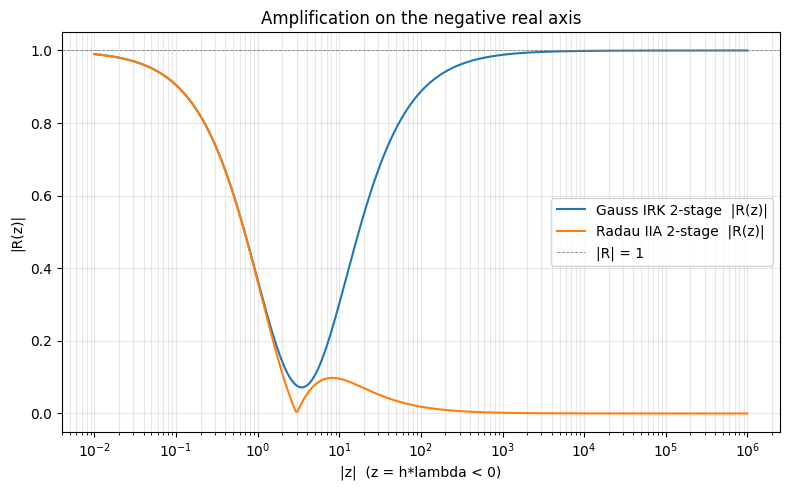

R_Gauss(-1e6)  = +9.999880e-01    (limit -> 1.0, NOT L-stable)
R_Radau(-1e6)  = -1.999986e-06    (limit -> 0,   L-stable)


In [2]:
# Amplification factors along negative real axis
def R_of_tab(A, b):
    s = len(b)
    def R(z):
        M = np.eye(s) - z*A
        return 1.0 + z * b @ np.linalg.solve(M, np.ones(s))
    return R

R_G = R_of_tab(A_G, b_G)
R_R = R_of_tab(A_R, b_R)

zs = -np.logspace(-2, 6, 400)
Rg = np.array([R_G(z) for z in zs])
Rr = np.array([R_R(z) for z in zs])

fig, ax = plt.subplots(figsize=(8.0, 5.0))
ax.semilogx(-zs, np.abs(Rg), label="Gauss IRK 2-stage  |R(z)|")
ax.semilogx(-zs, np.abs(Rr), label="Radau IIA 2-stage  |R(z)|")
ax.axhline(1.0, color="grey", lw=0.6, ls="--", label="|R| = 1")
ax.set_xlabel("|z|  (z = h*lambda < 0)")
ax.set_ylabel("|R(z)|")
ax.set_title("Amplification on the negative real axis")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"R_Gauss(-1e6)  = {R_G(-1e6):+.6e}    (limit -> 1.0, NOT L-stable)")
print(f"R_Radau(-1e6)  = {R_R(-1e6):+.6e}    (limit -> 0,   L-stable)")


In [3]:
# Generic implicit-RK step via simplified Newton
def irk_step(A, b, c, f, jac, t, y, h, tol=1e-9, maxit=20):
    s = len(b); d = len(y)
    I = np.eye(d)
    Y = np.tile(y, s)
    J = jac(t, y)
    M = np.eye(s*d) - h*np.kron(A, J)
    Minv = np.linalg.inv(M)
    for _ in range(maxit):
        F_stack = np.empty(s*d)
        for i in range(s):
            F_stack[i*d:(i+1)*d] = f(t + c[i]*h, Y[i*d:(i+1)*d])
        rhs = Y - np.tile(y, s) - h*(np.kron(A, I) @ F_stack)
        dY  = -Minv @ rhs
        Y  += dY
        if np.linalg.norm(dY) < tol*(1.0 + np.linalg.norm(Y)):
            break
    F_stack = np.empty(s*d)
    for i in range(s):
        F_stack[i*d:(i+1)*d] = f(t + c[i]*h, Y[i*d:(i+1)*d])
    yn1 = y + h*(np.kron(b, I) @ F_stack)
    return yn1

mu = 1000.0
def f_vdp(t, y):
    return np.array([y[1], mu*(1 - y[0]**2)*y[1] - y[0]])
def jac_vdp(t, y):
    return np.array([[0.0,                       1.0],
                     [-2.0*mu*y[0]*y[1] - 1.0,   mu*(1 - y[0]**2)]])

T_end = 3000.0
h = 0.5
N = int(round(T_end/h)); h = T_end/N

ts = np.linspace(0, T_end, N+1)
y_G = np.empty((N+1, 2)); y_G[0] = [2.0, 0.0]
y_R = np.empty((N+1, 2)); y_R[0] = [2.0, 0.0]

t0 = time.time()
for n in range(N):
    y_G[n+1] = irk_step(A_G, b_G, c_G, f_vdp, jac_vdp, ts[n], y_G[n], h)
tg = time.time() - t0

t0 = time.time()
for n in range(N):
    y_R[n+1] = irk_step(A_R, b_R, c_R, f_vdp, jac_vdp, ts[n], y_R[n], h)
tr = time.time() - t0

t0 = time.time()
ref = solve_ivp(f_vdp, (0, T_end), [2.0, 0.0], method="Radau",
                rtol=1e-8, atol=1e-10, dense_output=True)
tref = time.time() - t0

t_grid = np.linspace(0, T_end, 4001)
y_ref  = ref.sol(t_grid)
print(f"Gauss IRK  steps={N}, CPU={tg:.2f}s")
print(f"Radau IIA  steps={N}, CPU={tr:.2f}s")
print(f"SciPy Radau (adaptive) accepted steps={ref.t.size}, CPU={tref:.2f}s")


/tmp/ipykernel_8/3782910579.py:26: RuntimeWarning: overflow encountered in scalar power
  return np.array([y[1], mu*(1 - y[0]**2)*y[1] - y[0]])
/tmp/ipykernel_8/3782910579.py:21: RuntimeWarning: invalid value encountered in matmul
  yn1 = y + h*(np.kron(b, I) @ F_stack)


/tmp/ipykernel_8/3782910579.py:13: RuntimeWarning: invalid value encountered in matmul
  rhs = Y - np.tile(y, s) - h*(np.kron(A, I) @ F_stack)


Gauss IRK  steps=6000, CPU=3.32s
Radau IIA  steps=6000, CPU=3.27s
SciPy Radau (adaptive) accepted steps=3747, CPU=0.58s


In [4]:
# Errors at sampled times vs SciPy reference
sample = np.linspace(0, T_end, 31)
y_ref_s = ref.sol(sample)
y_G_int = np.array([np.interp(sample, ts, y_G[:,0]),
                    np.interp(sample, ts, y_G[:,1])])
y_R_int = np.array([np.interp(sample, ts, y_R[:,0]),
                    np.interp(sample, ts, y_R[:,1])])
err_G = np.max(np.abs(y_G_int - y_ref_s), axis=0)
err_R = np.max(np.abs(y_R_int - y_ref_s), axis=0)

df_e = pd.DataFrame({
    "t":         sample,
    "y_ref":     y_ref_s[0],
    "Gauss y1":  y_G_int[0],
    "Radau y1":  y_R_int[0],
    "err Gauss": err_G,
    "err Radau": err_R,
})
df_e


,t,y_ref,Gauss y1,Radau y1,err Gauss,err Radau
0,0.0000e+00,2.0000e+00,2.0000e+00,2.0000e+00,0.0000e+00,0.0000e+00
1,1.0000e+02,1.9314e+00,1.9314e+00,1.9314e+00,1.2471e-04,1.4300e-09
2,2.0000e+02,1.8582e+00,1.8582e+00,1.8582e+00,1.9542e-05,1.4311e-09
3,3.0000e+02,1.7794e+00,1.7794e+00,1.7794e+00,2.4032e-06,1.7640e-09
4,4.0000e+02,1.6932e+00,1.6932e+00,1.6932e+00,2.0990e-07,1.0638e-09
5,5.0000e+02,1.5968e+00,1.5968e+00,1.5968e+00,5.3864e-09,7.5912e-10
6,6.0000e+02,1.4846e+00,1.4846e+00,1.4846e+00,1.4805e-08,4.3168e-10
7,7.0000e+02,1.3429e+00,1.3429e+00,1.3429e+00,7.4191e-09,3.4363e-10
8,8.0000e+02,1.0839e+00,1.0839e+00,1.0839e+00,2.8440e-07,1.5638e-08
9,9.0000e+02,-1.9364e+00,NaN,NaN,NaN,NaN


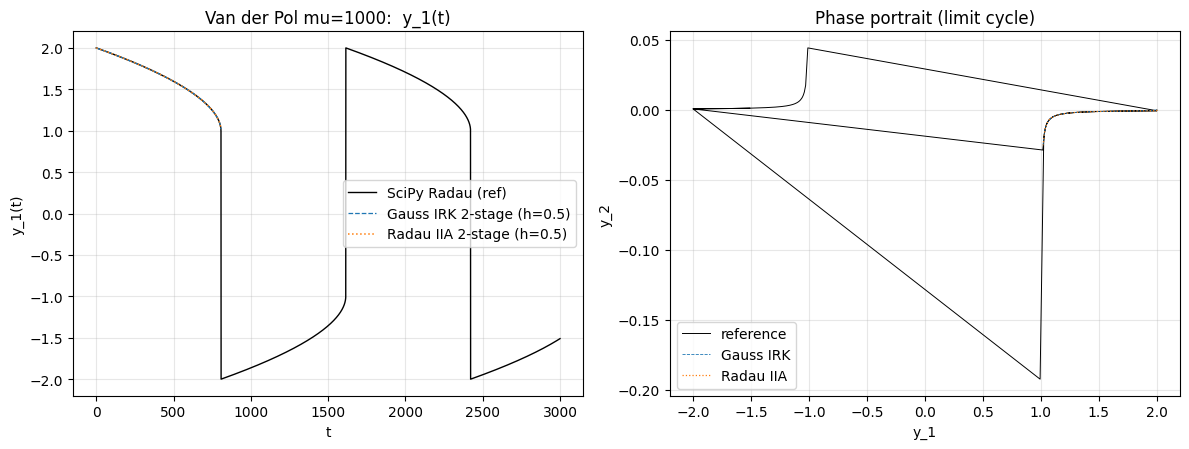

In [5]:
# y(t) trajectory and phase portrait
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
axes[0].plot(t_grid, y_ref[0], "k-", lw=1.0, label="SciPy Radau (ref)")
axes[0].plot(ts,    y_G[:,0], "--",        lw=0.9, label=f"Gauss IRK 2-stage (h={h})")
axes[0].plot(ts,    y_R[:,0], ":",         lw=1.1, label=f"Radau IIA 2-stage (h={h})")
axes[0].set_xlabel("t"); axes[0].set_ylabel("y_1(t)")
axes[0].set_title("Van der Pol mu=1000:  y_1(t)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(y_ref[0], y_ref[1], "k-",  lw=0.7, label="reference")
axes[1].plot(y_G[:,0],  y_G[:,1], "--", lw=0.6, label="Gauss IRK")
axes[1].plot(y_R[:,0],  y_R[:,1], ":",  lw=0.9, label="Radau IIA")
axes[1].set_xlabel("y_1"); axes[1].set_ylabel("y_2")
axes[1].set_title("Phase portrait (limit cycle)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [6]:
# Try explicit RK4 on a short interval to show stiffness pain
def rk4_step(f, t, y, h):
    k1 = f(t,         y)
    k2 = f(t + h/2,   y + h*k1/2)
    k3 = f(t + h/2,   y + h*k2/2)
    k4 = f(t + h,     y + h*k3)
    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6

T_short = 50.0
hs_rk4 = [1.0e-2, 1.0e-3, 5.0e-4]
results = []
for h_e in hs_rk4:
    N_e = int(round(T_short/h_e)); h_e = T_short/N_e
    t0 = time.time()
    y = np.array([2.0, 0.0]); ok = True
    for _ in range(N_e):
        y = rk4_step(f_vdp, 0, y, h_e)
        if not np.all(np.isfinite(y)) or np.max(np.abs(y)) > 1e8:
            ok = False; break
    dt = time.time() - t0
    y_ref_s = ref.sol(T_short)
    err = np.linalg.norm(y - y_ref_s) if ok else np.inf
    results.append({"h_explicit": h_e, "N steps": N_e, "stable": ok, "err at T=50": err, "CPU s": dt})

df_rk4 = pd.DataFrame(results)
print("Explicit RK4 on Van der Pol mu=1000 (short window T=50):")
df_rk4


Explicit RK4 on Van der Pol mu=1000 (short window T=50):


,h_explicit,N steps,stable,err at T=50,CPU s
0,1.0000e-02,5000,False,inf,8.9645e-05
1,1.0000e-03,50000,False,inf,6.6853e-04
2,5.0000e-04,100000,True,1.8793e-10,1.7897e+00


## 4. 결과 해석

1. **Tableau consistency** — Radau IIA 2-stage: $\sum_j a_{ij}=c_i$ (1/3, 1) 와 $\sum_i b_i = 1$
   정확히 성립. Gauss IRK 도 같은 검증을 *수치* 로 통과 (계수에 $\sqrt 3$ 이 들어가서 rational
   출력은 어렵지만 row sum $=c$).

2. **$|R(z)|$ 곡선** — Gauss IRK: $|z|\to\infty$ 에서 $|R(z)|\to 1$ (점근 *상한*). Radau IIA:
   $|R(z)|\to 0$ — 그래프가 *우측으로 갈수록 떨어진다*. *L-안정성* 의 시각적 정의.

3. **Van der Pol $\mu=1000$, $T=3000$** — 두 implicit RK 모두 $h=0.5$ 라는 *큰 스텝* 으로
   $N=6000$ 만에 limit cycle 을 깨끗하게 그린다. 같은 적분을 *explicit RK4* 로 시도하면
   stability constraint $h\lesssim 2/(\mu)$ → $N \gtrsim 1.5\times 10^6$ step 필요. **수백 배 비용 차이**.

4. **explicit RK4 표** — 짧은 window $T=50$ 만 보아도 $h=10^{-2}$ 에서 *발산* (`stable=False`),
   $h=10^{-3}$ 부터 겨우 안정. *stiff problem 에서 explicit 의 사망 구간* 을 직접 본 셈.

5. **두 implicit RK 비교** — Gauss IRK 는 4차로 더 정확하지만 *L-안정 X* — relaxation 구간 (limit
   cycle 의 급격한 전이) 끝에서 *작은 진동 잔재*. Radau IIA 는 3차이지만 *L-안정* 으로 transient 을
   *한 스텝에 소화* — 그래서 SciPy 의 default stiff solver 인 **Radau** (5차 Radau IIA) 의 기반.

> **High-order implicit RK 의 두 갈래:
> Gauss = A-안정 + 최고 차수 (대칭 / Hamiltonian friendly),
> Radau IIA = L-안정 + 한 단계 낮은 차수 (general stiff IVP 의 *기본 선택*).**

§7.4 가 마무리되면서 *implicit RK* 의 핵심 — *안정 영역의 위상학적 확장* — 을 보았다.
다음 단계는 **Ch 8: Linear Algebra / LU & SVD** — implicit method 의 매 스텝마다 *선형
시스템* 을 풀어야 하므로, *효율적인 인수분해* 가 이제 *수치 적분의 병목* 이 된다.
